In [1]:
import numpy as np
import matplotlib.pyplot as plt

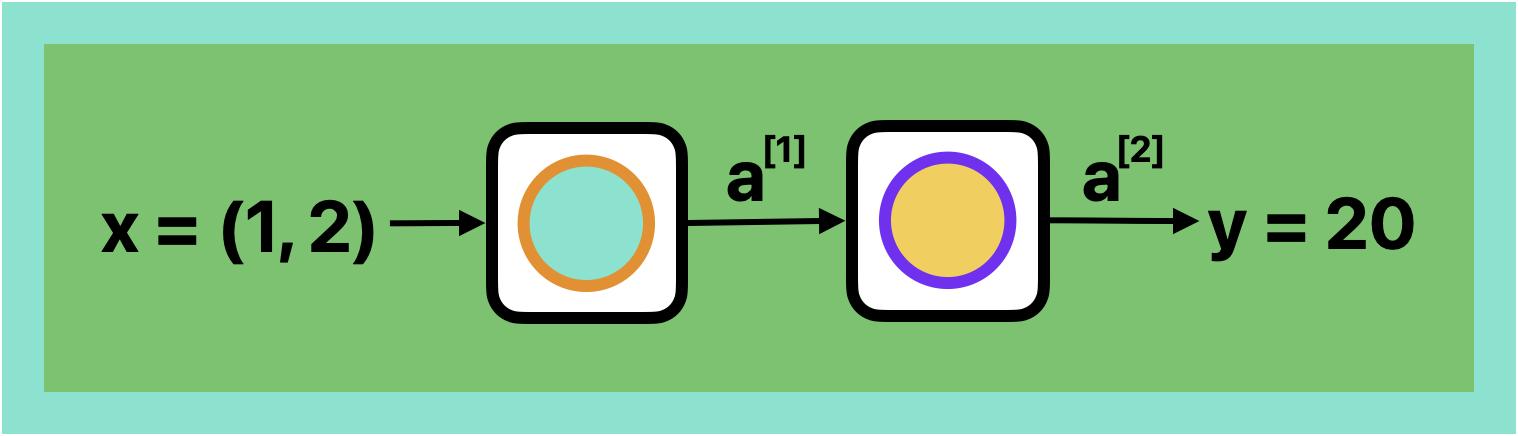

In [2]:
x = np.array([1.0, 2.0])
y = 20.0

In [3]:
def compute_cost(x, y, w1, b1, w2, b2):
    a1 = w1[0] * x[0] + w1[1] * x[1] + b1
    a2 = w2[0] * a1 + b2

    J = 1 / 2 * (a2 - y) ** 2
    return J

In [4]:
def compute_gradient(x, y, w1, b1, w2, b2):
    a1 = w1[0] * x[0] + w1[1] * x[1] + b1
    a2 = w2[0] * a1 + b2

    error = a2 - y

    # use index from 1 for variables
    dj_dw1_1 = error * w2[0] * x[0]
    dj_dw1_2 = error * w2[0] * x[1]
    dj_db1 = error * w2[0]

    dj_dw2 = error * a1
    dj_db2 = error

    return dj_dw1_1, dj_dw1_2, dj_db1, dj_dw2, dj_db2

In [5]:
def compute_gradient_descent(x, y, n_iter=100):
    w1 = np.array([1.0, 1.0])
    b1 = 0
    w2 = np.array([1.0])
    b2 = 0

    cost_history = []

    alpha = .001

    for i in range(1, n_iter+1):
        dj_dw1_1, dj_dw1_2, dj_db1, dj_dw2, dj_db2 = compute_gradient(
            x, y, w1, b1, w2, b2)

        w1[0] = w1[0] - alpha * dj_dw1_1
        w1[1] = w1[1] - alpha * dj_dw1_2
        b1 = b1 - alpha * dj_db1
        w2[0] = w2[0] - alpha * dj_dw2
        b2 = b2 - alpha * dj_db2

        cost = compute_cost(x, y, w1, b1, w2, b2)
        cost_history.append(cost)

        if i % 10 == 0:
            cost = compute_cost(x, y, w1, b1, w2, b2)
            print(f"Iteration {i:<4}: {cost:>10.5f}")
            
    print("\nw1 and b1:", w1, b1)
    print("w2 and b2:", w2, b2)

    return w1, b1, w2, b2, cost_history

In [6]:
def predict(x, w1, b1, w2, b2):
    a1 = w1[0] * x[0] + w1[1] * x[1] + b1
    a2 = w2[0] * a1 + b2

    return a2

*gradient_descent, cost_history = compute_gradient_descent(x, y)

test_x = [1.0, 2.0]
p = predict(x, *gradient_descent)

print(f"\nPredict: {test_x}: {p}")

Iteration 10  :   90.56756
Iteration 20  :   37.55596
Iteration 30  :    9.65838
Iteration 40  :    1.73013
Iteration 50  :    0.25577
Iteration 60  :    0.03483
Iteration 70  :    0.00460
Iteration 80  :    0.00060
Iteration 90  :    0.00008
Iteration 100 :    0.00001

w1 and b1: [1.67279781 2.34559562] 0.6727978104557669
w2 and b2: [2.78666465] 0.38634087388231936

Predict: [1.0, 2.0]: 19.995506095590056


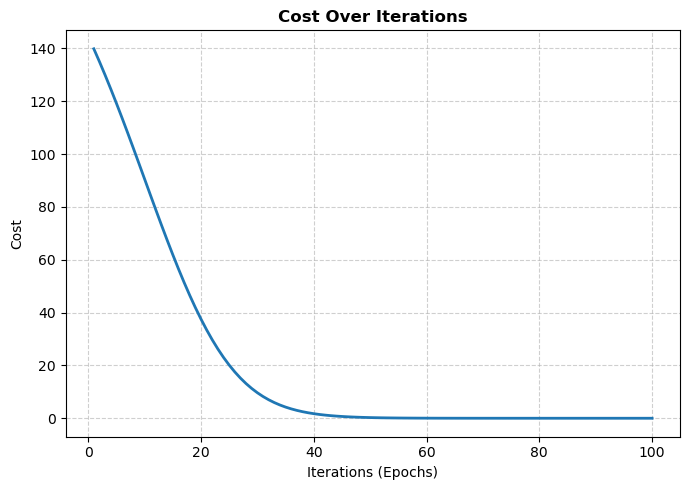

In [7]:
iter_range = range(1, len(cost_history) + 1)

plt.figure(figsize=(7, 5))
plt.plot(iter_range, cost_history, linewidth=2, label='Training Cost')

plt.title('Cost Over Iterations', fontweight='bold')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Cost')

plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
